# Assignment 1: Student Performance Prediction
### Task:

Is dataset par **Linear Regression** apply karni hai aur **Exam Score** ko predict karna hai.

**Target Column (Prediction):**

* `Exam_Score`

Baaki numeric columns ko features ke taur par use karein.

### Submission Requirements:

* Complete Jupyter Notebook (.ipynb)
* Dataset
* Proper comments in code
* Model Evaluation (MAE, MSE, RMSE, R² Score)
* Prediction Results

**Submission Deadline:**
**29 July 2026 (29/07/2026)**

Apna complete project GitHub par upload karein aur GitHub repository ka link submit karein.

In [410]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [411]:
df = pd.read_csv(r'student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [412]:
print(f'Numbers of Rows = {df.shape[0]} \nNumbers of Columns = {df.shape[1]}')

Numbers of Rows = 1000 
Numbers of Columns = 16


In [413]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='str')

In [414]:
df.drop(columns = ['student_id'], inplace = True)

In [415]:
df.head(3)

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3


In [416]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   str    
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   str    
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   str    
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    str    
 11  internet_quality               1000 non-null   str    
 12  mental_health_rating           1000 non-null   int64  
 13  

In [417]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [418]:
df.describe(include = [object])

,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,909,1000,1000
unique,3,2,3,3,3,2
top,Female,No,Fair,High School,Good,No
freq,481,785,437,392,447,682


In [419]:
df.isnull().sum()

age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [420]:
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [421]:
df.isnull().sum()

age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [422]:
df.duplicated().sum()

np.int64(0)

In [423]:
numerical_columns = df.select_dtypes(include = [int, float]).columns
categorical_columns = df.select_dtypes(include = [object]).columns

print(f'Lenght of numerical columns is {len(numerical_columns)}')
print(f'Lenght of categorical columns is {len(categorical_columns)}')

Lenght of numerical columns is 9
Lenght of categorical columns is 6


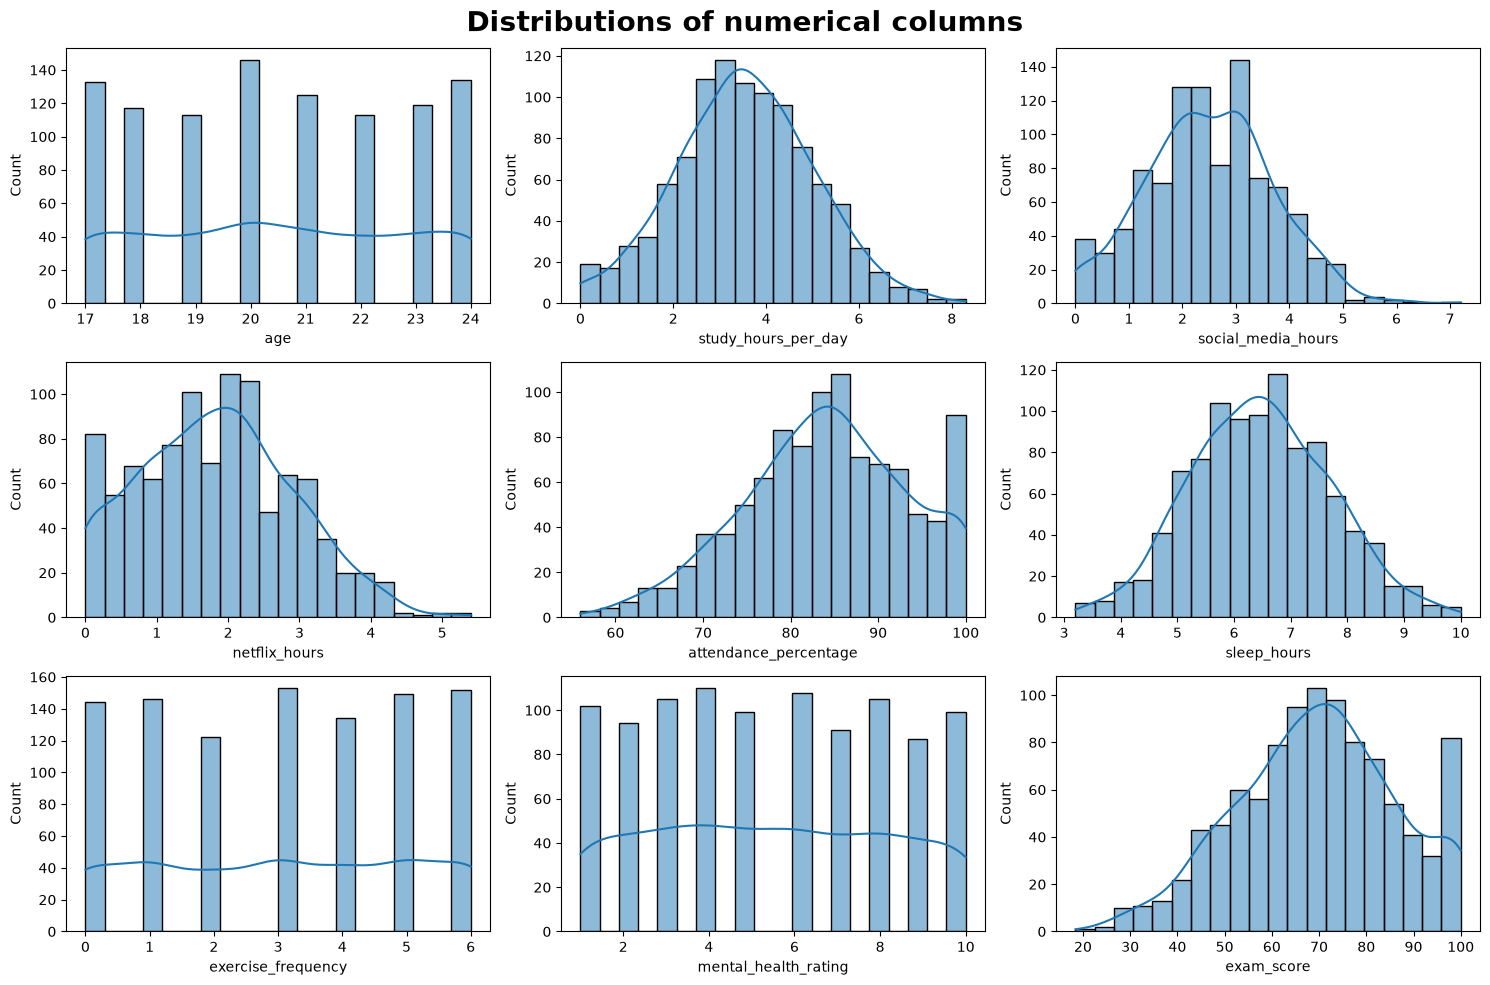

In [424]:
fig, axes = plt.subplots(3, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.histplot(
        data = df,
        x = col,
        bins = 20,
        kde = True,
        ax = ax
    )

plt.suptitle('Distributions of numerical columns', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

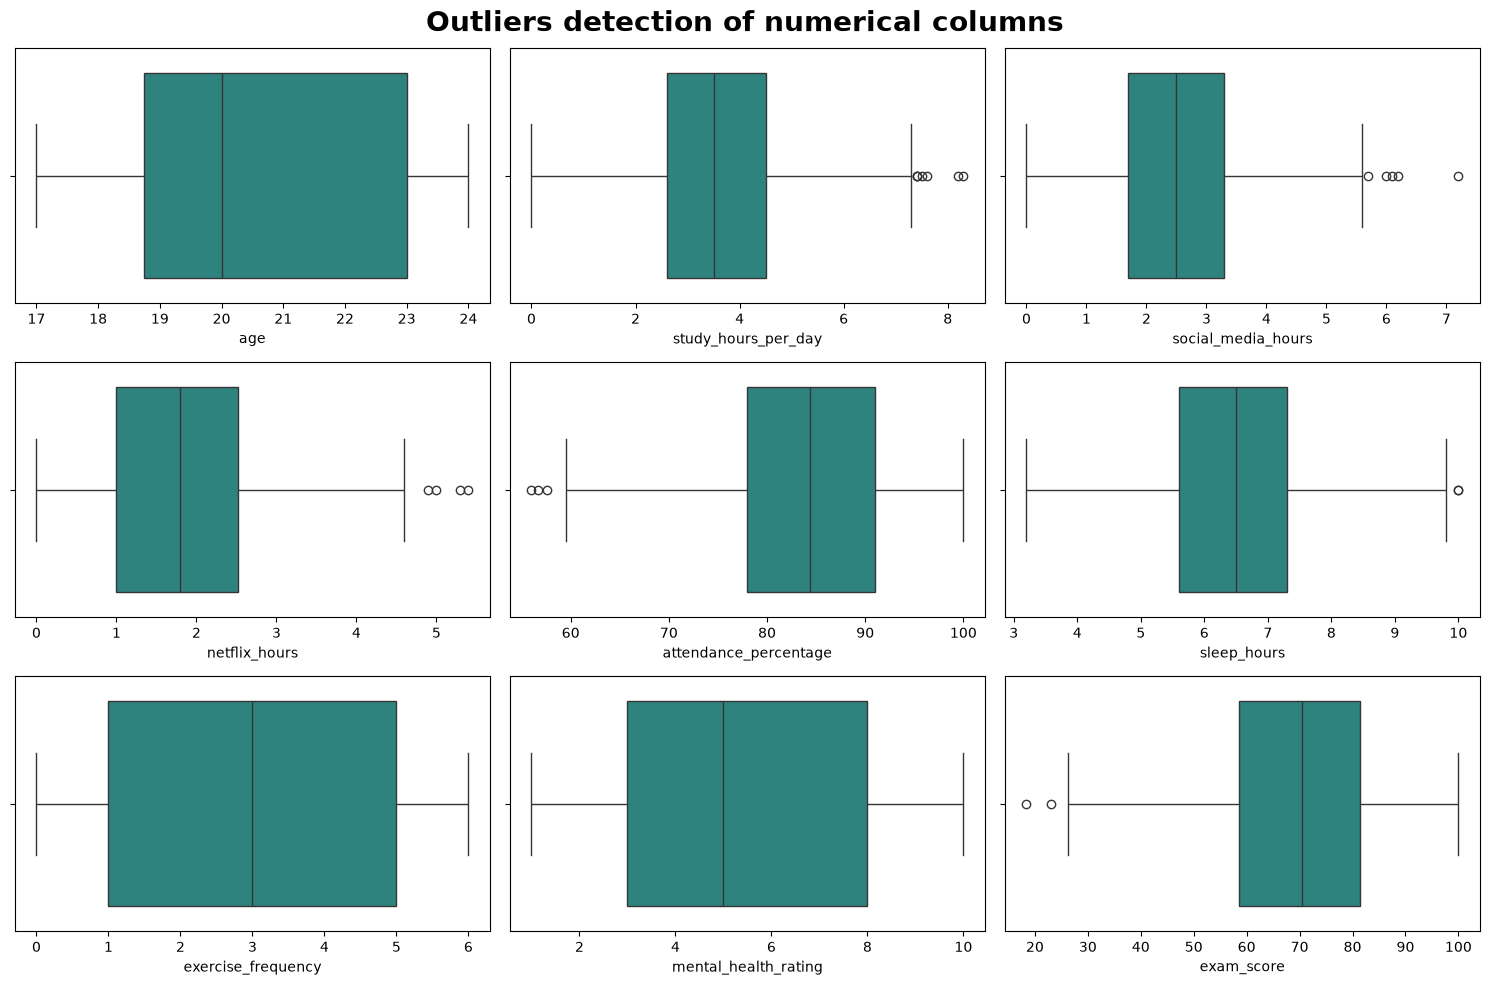

In [425]:
fig, axes = plt.subplots(3, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.boxplot(
        data = df,
        x = col,
        palette = 'viridis',
        ax = ax
    )

plt.suptitle('Outliers detection of numerical columns', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [426]:
outliered_columns = ['study_hours_per_day', 'social_media_hours', 'netflix_hours']

for col in outliered_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower = lower_bound, upper = upper_bound)
    print(col, " Done")

study_hours_per_day  Done
social_media_hours  Done
netflix_hours  Done


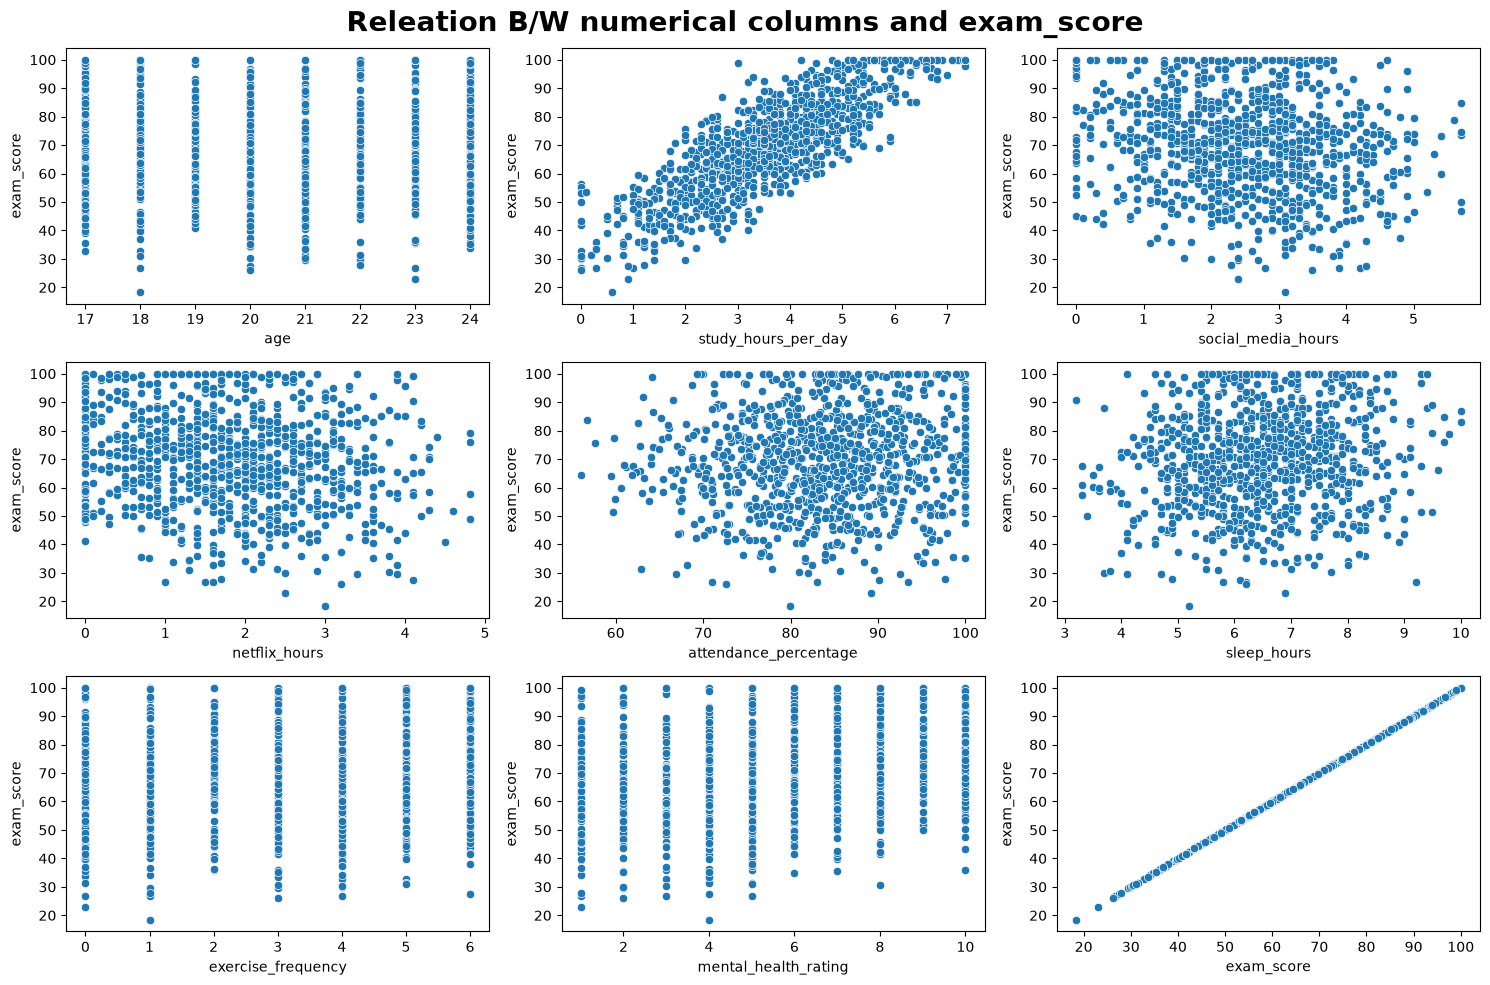

In [427]:
fig, axes = plt.subplots(3, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.scatterplot(
        data = df,
        x = col,
        y = 'exam_score',
        palette = 'viridis',
        ax = ax
    )

plt.suptitle('Releation B/W numerical columns and exam_score', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

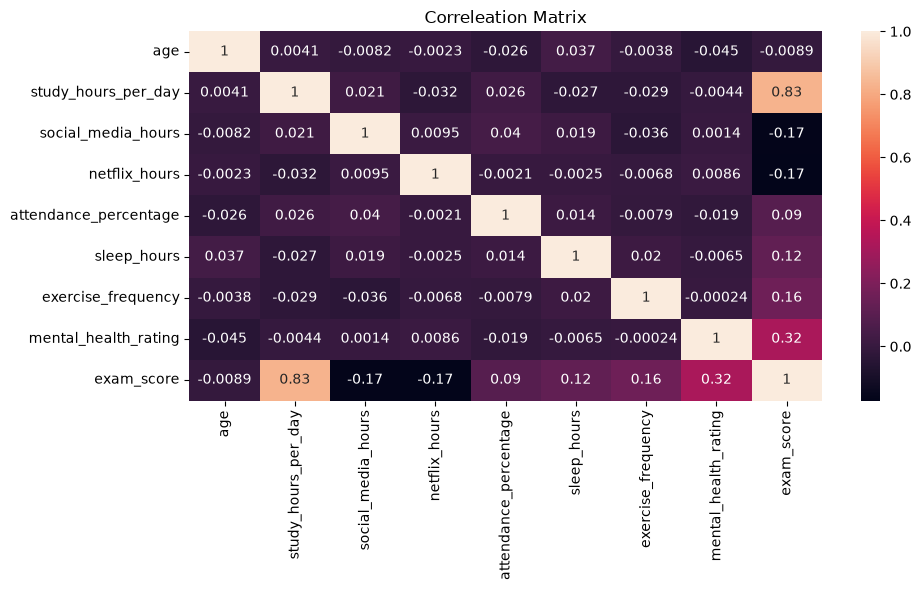

In [428]:
plt.figure(figsize = (10, 6))
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.title('Correleation Matrix')
plt.tight_layout()
plt.show()

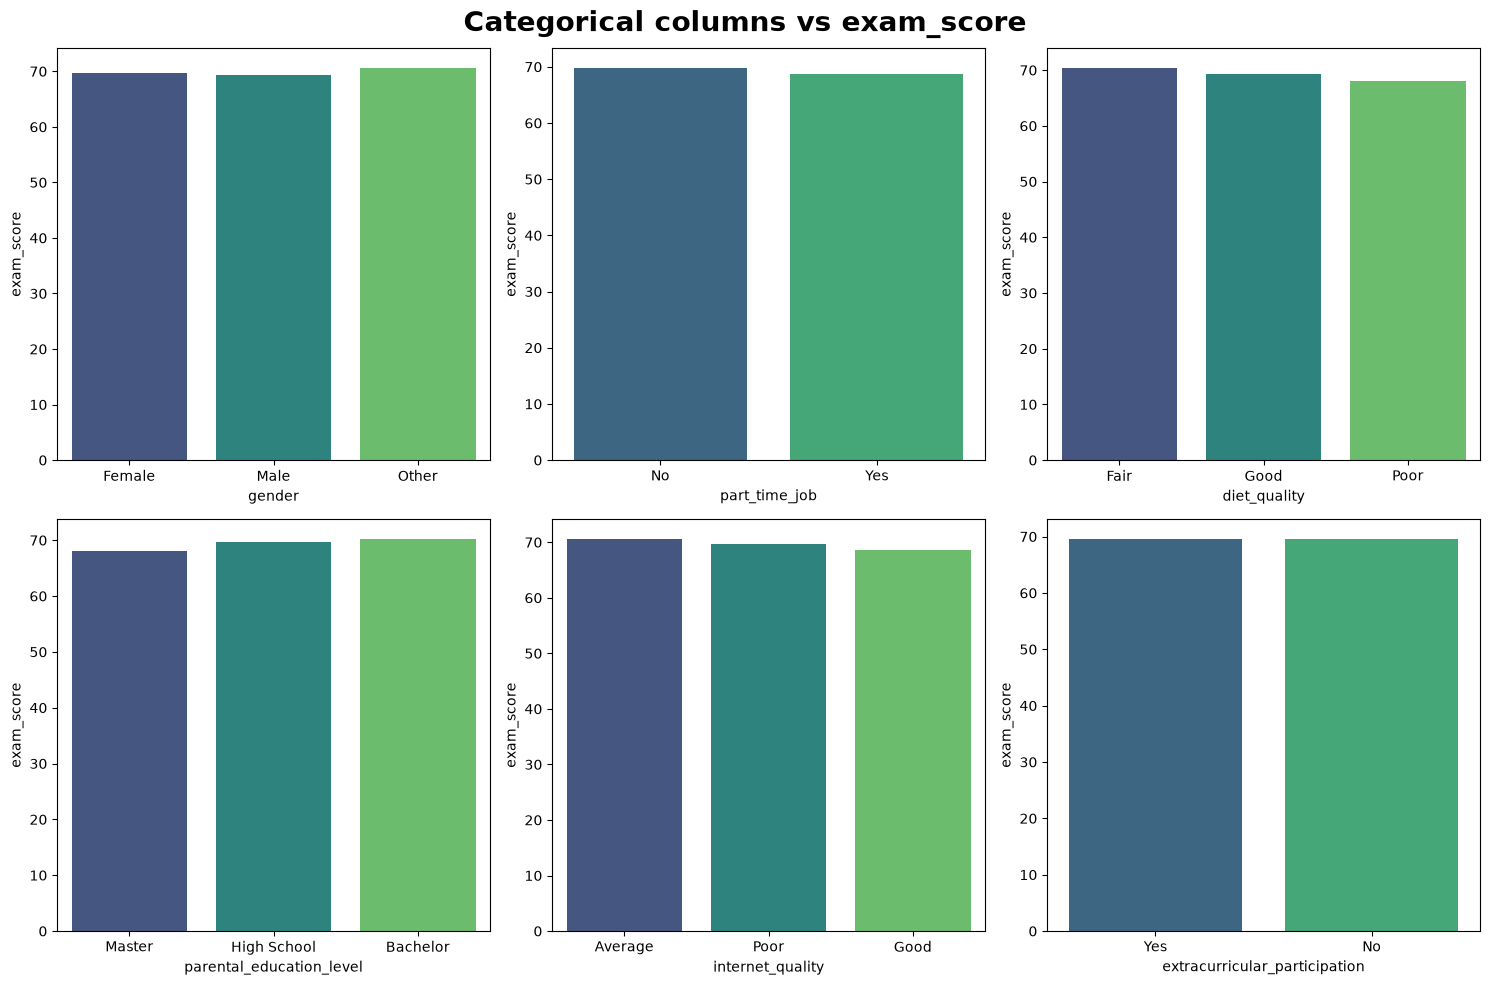

In [429]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    sns.barplot(
        data = df,
        x = col,
        y = 'exam_score',
        ax = ax,
        palette = 'viridis',
        errorbar = None
    )

plt.suptitle('Categorical columns vs exam_score', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

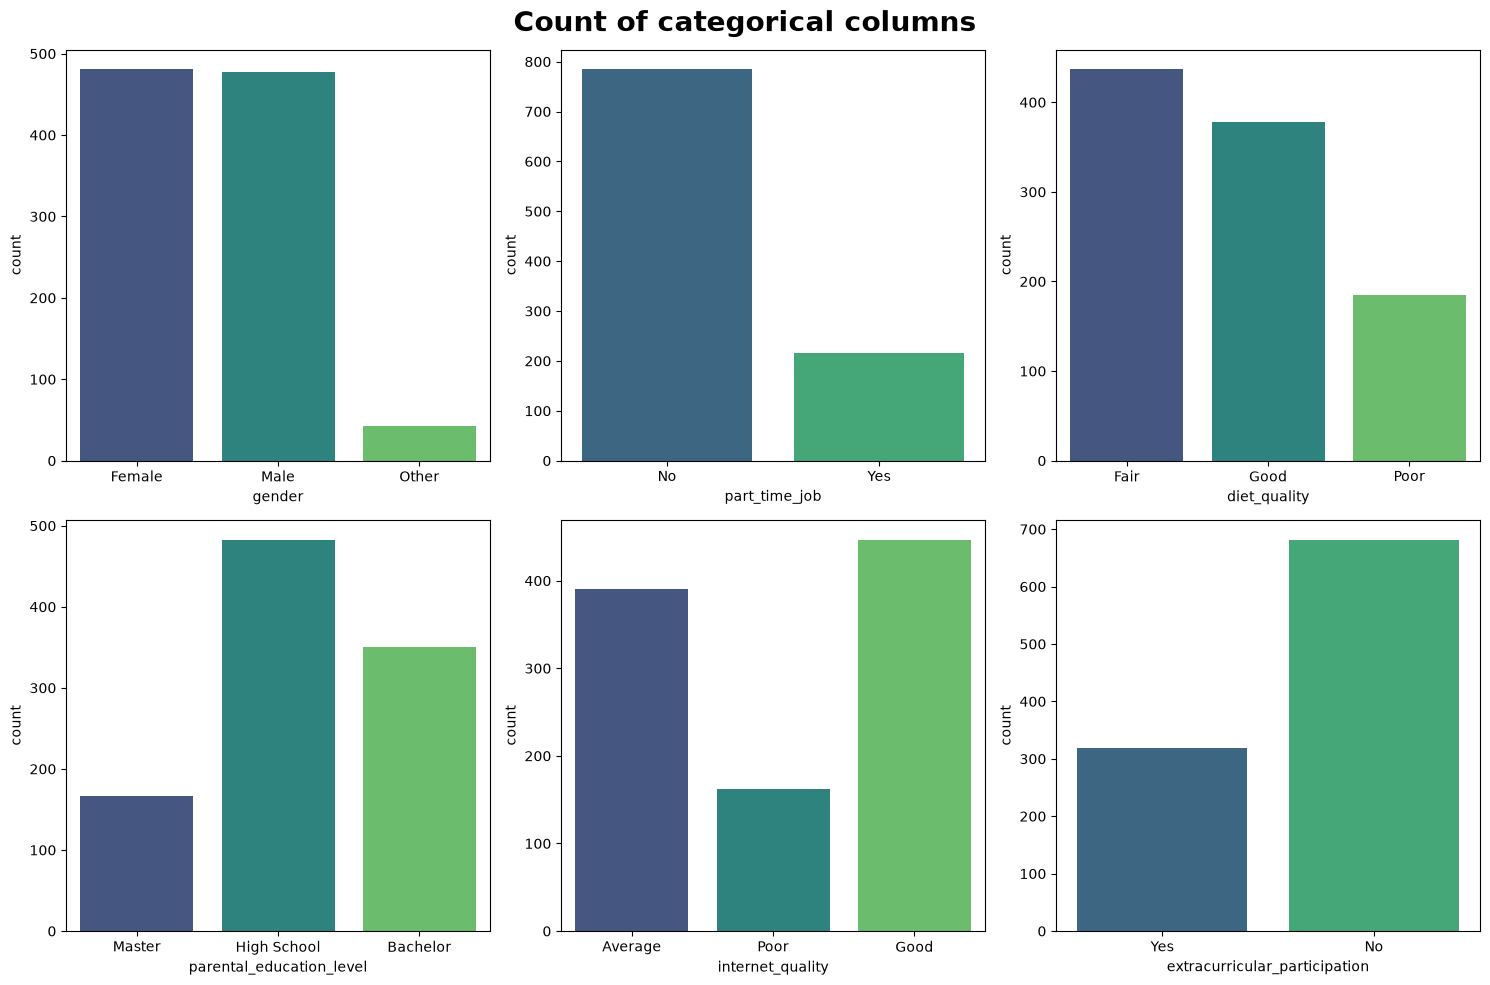

In [430]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    sns.countplot(
        data = df,
        x = col,
        ax = ax,
        palette = 'viridis',
    )

plt.suptitle('Count of categorical columns', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [431]:
df = pd.get_dummies(df, drop_first = True, dtype = int)

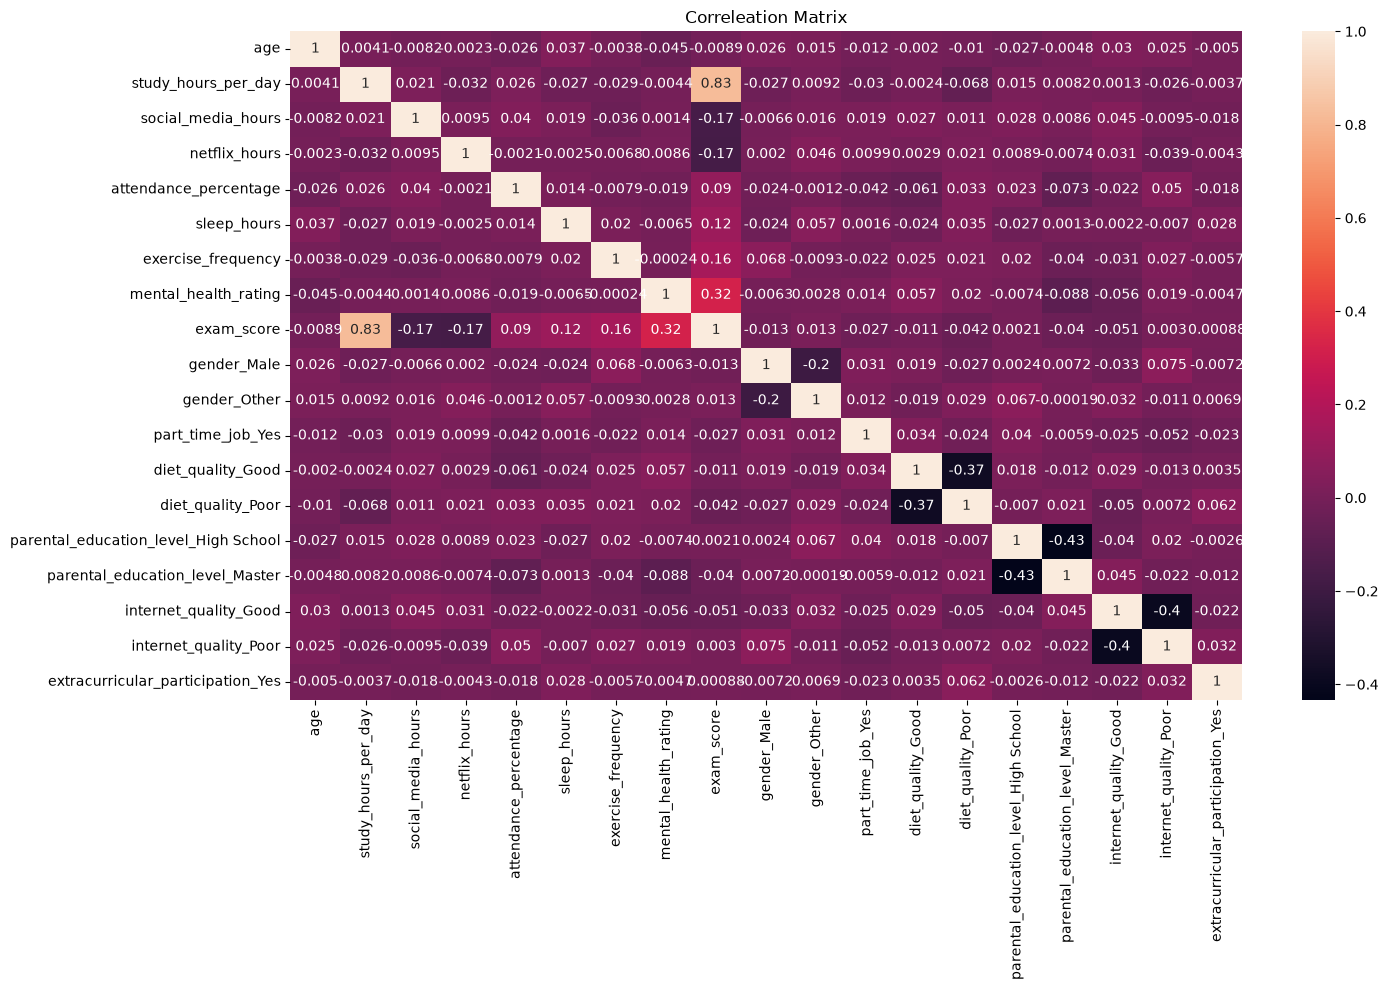

In [432]:
plt.figure(figsize = (15, 10))
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.title('Correleation Matrix')
plt.tight_layout()
plt.show()

In [433]:
X = df[[
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating'
]]
y = df['exam_score']

In [434]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [435]:
pf = PolynomialFeatures(degree = 2)
X_train = pf.fit_transform(X_train)
X_test = pf.transform(X_test)

In [436]:
LR = LinearRegression()
LR.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[-0. ,11.76,-4.57,..., 0.02,-0.08, 0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,16.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(27)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](28,)","[1151.67, 673.54, 512.79,..., 4.4 , 3.21, 0. ]"


## Train R2 Score

In [437]:
y_pred_train = LR.predict(X_train)

print(f'Train Accuracy : {r2_score(y_train, y_pred_train) * 100:.2f}%')

Train Accuracy : 90.27%


## Test R2 Score

In [438]:
y_pred_test= LR.predict(X_test)

print(f'Test Accuracy : {r2_score(y_test, y_pred_test) * 100:.2f}%')

Test Accuracy : 90.28%


## RMSE & MAE

In [439]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Train RMSE : {rmse_train:.2f}")
print(f"Train MAE : {mae_train:.2f}")
print(f"Test RMSE  : {rmse_test:.2f}")
print(f"Test MAE  : {mae_test:.2f}")

Train RMSE : 5.33
Train MAE : 4.27
Test RMSE  : 4.99
Test MAE  : 4.08


## Python script

In [440]:
df[[
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating',
]].head(1)

,study_hours_per_day,social_media_hours,netflix_hours,sleep_hours,exercise_frequency,mental_health_rating
0,0.0,1.2,1.1,8.0,6,8


In [441]:
df['exam_score'].head(1).reset_index()

,index,exam_score
0,0,56.2


In [442]:
# User se input lo
print("\nEnter new Student Details here:")
sh = float(input("Study hours per day: "))
sm = float(input("Social media hours: "))
nf = float(input("Netflix hours: "))
sl = float(input("Sleep hours: "))
ex = float(input("Exercise frequency (1-5): "))
mh = float(input("Mental health rating (1-5): "))

new_data = [[sh, sm, nf, sl, ex, mh]]
new_data_poly = pf.transform(new_data)
score = LR.predict(new_data_poly)

print(f"Predicted Score: {score[0]:.2f}")


Enter new Student Details here:


Study hours per day:  0
Social media hours:  1.2
Netflix hours:  1.1
Sleep hours:  8.0
Exercise frequency (1-5):  6
Mental health rating (1-5):  8


Predicted Score: 52.43


#### Actual score = 56.2 
#### Predicted score = 52.4